In [ ]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.interpolate import interp1d
import time as _time

FILE_PATH = os.getcwd()
import plot_settings
plot_settings.apply()

COLORS    = plot_settings.colors()

In [24]:
HF_model = 'pybamm'
if HF_model == 'comsol':
    name = 'data/polished_CC'
    file = 'merged_data_hyper.txt'
elif HF_model == 'pybamm':
    name = 'data_pybamm/pulse'
    file = 'pybamm_pulse.txt'

DATA_DIR  = os.path.join(FILE_PATH, name)
DATA_FILE = os.path.join(DATA_DIR, file)
DT        = 1.0

LIMS = {
    'R0': (0.001, 5),
    'R1': (0.001, 100),
    'C1': (100, 4e4)
    }

In [25]:
# ── Load data ──────────────────────────────────────────────
data = pd.read_csv(DATA_FILE, sep=';', comment='%')
data['eta'] = -data['eta']
# Build OCV interpolator from data (same as battery models)
_s, _u = data['soc'].values, data['Ue'].values
_i = np.argsort(_s)
Ue_interp = interp1d(_s[_i], _u[_i], kind='linear', fill_value='extrapolate')

print(f"  {len(data)} pts, {data['trajectory'].nunique()} trajectories")

# # ── Build trajectories ─────────────────────────────────────
# def prepare_data(data):
#     trajs = []
#     for _, grp in data.sort_values(['trajectory', 't']).groupby('trajectory'):
#         grp = grp.reset_index(drop=True)
#         I_val, u_val = float(grp['I']), float(grp['u'].iloc[0])
#         soc_arr = grp['soc'].values.astype(np.float32)
#         trajs.append(dict(
#             I       = I_val,
#             u       = u_val,
#             soc0    = float(grp['soc'].iloc[0]),
#             T       = len(grp),
#             t       = np.arange(len(grp)) * DT,
#             i_profile = np.full(len(grp), I_val, dtype=np.float32),
#             ocv     = Ue_interp(soc_arr),          # OCV from interp, same as Ue
#             V_true  = grp['V'].values.astype(np.float32),
#             soc_true = soc_arr,
#             eta      = grp['eta'].values.astype(np.float32),
#             c       = grp['C'].values.astype(np.float32),
#         ))
#     return trajs

# # trajs = prepare_data(data)
# # print(f"  {len(trajs)} trajectories prepared")
# # print(trajs[0].keys())

  360000 pts, 100 trajectories


In [26]:
# --- ODE solver---
def ecm_solve_fix(theta, I, t, U0=0.0):
    """Integrate ECM with constant [R0, R1, C1]. Return eta(t)."""
    R0, R1, C1 = theta
    I_interp = interp1d(t, I, fill_value='extrapolate')
    def dU1(u, t_):
        return -u / (R1 * C1) + I_interp(t_) / C1
    U1 = scipy.integrate.odeint(dU1, U0, t).flatten()
    return I * R0 + U1

def fit_ecm_fix(tr_ref, *, DC=True, p0=(0.01, 0.05, 5000), lims=LIMS, print_elem= True):
    """Fit constant [R0, R1, C1] on one reference trajectory."""
    bounds = ([lims['R0'][0], lims['R1'][0], lims['C1'][0]],
              [lims['R0'][1], lims['R1'][1], lims['C1'][1]])
    if DC:
        xdata = [tr_ref['t'], tr_ref['I']*np.ones_like(tr_ref['t'])]
    else:
        xdata = [tr_ref['t'], tr_ref['I_seq']] if 'I_seq' in tr_ref else [tr_ref['t'], tr_ref['I']]
    eta = np.asarray(-tr_ref['eta'])
    def _fwd(x, R0, R1, C1):
        _t, _I = x
        return ecm_solve_fix((R0, R1, C1), _I, _t)
    popt, _ = scipy.optimize.curve_fit(_fwd, xdata, eta,
                                       p0=list(p0), bounds=bounds)
    
    if print_elem:
        print(f"Fitted parameters: R0={popt[0]:.4f} Ω, R1={popt[1]:.4f} Ω, C1={popt[2]:.1f} F")
    return popt                                   # ndarray([R0, R1, C1])


def predict_ecm_fix(tr, theta):
    """Apply fitted theta to any trajectory; V_B sampled at tr['t']."""
    t = np.asarray(tr['t'])
    I = np.asarray(tr['I_seq'] if 'I_seq' in tr
                   else float(tr['I']) * np.ones_like(t))
    return -ecm_solve_fix(theta, I, t) + np.asarray(tr['ocv'])

In [27]:
def ECM_solve_du(theta, i, t, RC2 = False, U0 = 0):

    # Create interpolation function ONCE
    I_interp = interp1d(t, i, fill_value="extrapolate")

    def dU(u, t,R,C):
        I_t = I_interp(t)
        return -u / (R * C) + I_t / C 

    # Solve ODE
    
    U1 = scipy.integrate.odeint(dU, U0, t, args=(theta[1],theta[2])).flatten()

    if RC2:
        U2 = scipy.integrate.odeint(dU, U0, t, args=(theta[3],theta[4])).flatten()
    else: 
        U2 = 0
    #U2 = 0

    U = U1 + U2
    # Voltage model
    eta_model =  i*theta[0] + U

    return eta_model

def ECM_solve_curvefit(x, R0, R1, C1):
    t, i = x
    eta_model = ECM_solve_du(theta=[R0, R1, C1], i=i, t=t)
    return eta_model

def dSOC_dt(z,t, i):              # SOC ODE
    return  -i / 3600

def parameter_estimation_curvefit(tr, p0=[0.01, 0.01, 1500],lims = LIMS, U0 = 0):
    bounds = ([lims['R0'][0], lims['R1'][0], lims['C1'][0]], [lims['R0'][1], lims['R1'][1], lims['C1'][1]])
    xdata = [tr['t'], tr['I']*np.ones_like(tr['t'])]
    ydata = -tr['eta']
    popt, pcov = scipy.optimize.curve_fit(ECM_solve_curvefit, xdata, ydata, p0=p0, bounds=bounds)
    R0, R1 , C1 = popt
    eta = ECM_solve_curvefit(xdata, R0, R1, C1)
    return R0, R1, C1,-eta + tr['Ue']

,u_par,C,t,V,I,F,u,Ue,soc,eta,pulse,trajectory
0,0,0.000000,0.000000,3.851821,0.000000,0,0,3.851821,1.000000,4.440892e-16,True,5
1,0,0.606034,1.000278,3.778251,0.606034,0,0,3.851821,0.999916,-7.356916e-02,True,5
2,0,0.606034,2.000556,3.777020,0.606034,0,0,3.851715,0.999747,-7.469526e-02,True,5
3,0,0.606034,3.000834,3.776082,0.606034,0,0,3.851609,0.999579,-7.552695e-02,True,5
4,0,0.606034,4.001111,3.775311,0.606034,0,0,3.851503,0.999411,-7.619256e-02,True,5


Fitted parameters: R0=0.1289 Ω, R1=0.0206 Ω, C1=1504.1 F


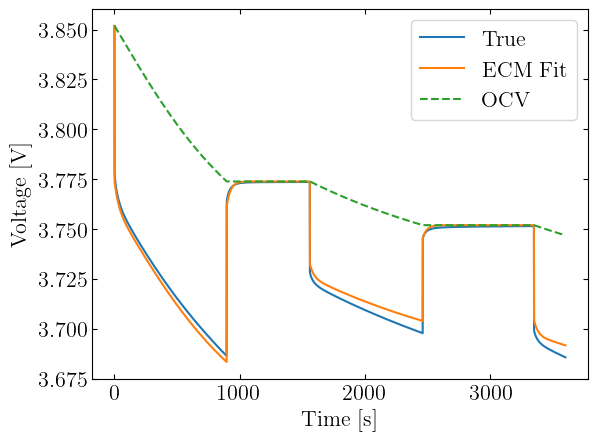

In [28]:

trajs = data[data['trajectory'] == 5].reset_index(drop=True)
display(trajs.head())
R0,R1,C1,V_ecm = parameter_estimation_curvefit(trajs, p0=[0.1, 0.01, 1500], lims=LIMS)

# tr = trajs[0] 
# xdata = [tr['t'], tr['I']*np.ones_like(tr['t'])]
# R0 = 0.1; R1 = 0.3; C1 = 1000
# V_ecm = -ECM_solve_curvefit(xdata, R0, R1, C1) + tr['ocv']

print(f"Fitted parameters: R0={R0:.4f} Ω, R1={R1:.4f} Ω, C1={C1:.1f} F")

#V_ecm = ecm_solve_fix([0.01,0.01,1000], trajs[0]['I']*np.ones_like(trajs[0]['t']), trajs[0]['t'])
plt.plot(trajs['t'], trajs['V'], label='True')
plt.plot(trajs['t'], V_ecm, label='ECM Fit')
plt.plot(trajs['t'], trajs['Ue'], label='OCV', linestyle='dashed')
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.show()